#  Common imports & helpers 

In [50]:

import numpy as np
import time, os, math, gc, tempfile, shutil
from collections import defaultdict
from typing import List, Tuple, Dict
import matplotlib.pyplot as plt

# Reproducibility
SEED = 2
rng = np.random.default_rng(SEED)

def precision_at_k(true_neighbors: List[int], approx_neighbors: List[int], k: int) -> float:
    inter = len(set(true_neighbors[:k]) & set(approx_neighbors[:k]))
    return inter / max(1, len(approx_neighbors[:k]))

def recall_at_k(true_neighbors: List[int], approx_neighbors: List[int], k: int) -> float:
    inter = len(set(true_neighbors[:k]) & set(approx_neighbors[:k]))
    return inter / max(1, len(true_neighbors[:k]))

def evaluate_knn_lists(true_nn: List[List[int]],
                       approx_nn: List[List[int]],
                       k: int) -> Tuple[float, float]:
    P, R = 0.0, 0.0
    n = len(true_nn)
    for i in range(n):
        P += precision_at_k(true_nn[i], approx_nn[i], k)
        R += recall_at_k(true_nn[i], approx_nn[i], k)
    return P / n, R / n

def time_call(fn, *args, **kwargs):
    t0 = time.time()
    out = fn(*args, **kwargs)
    return out, time.time() - t0

def mb(x_bytes: int) -> float:
    return x_bytes / (1024**2)

# Common k sweep
K_LIST = [1, 2, 3, 5, 10, 20, 50, 100]



#  Dataset 1: Overlapping Gaussians

In [51]:

from sklearn.preprocessing import StandardScaler

def overlapping_gaussians(n=50_000, k=4, dim=32, gap=1.0, std=1.2, seed=SEED):
    rng = np.random.default_rng(seed)
    centers = rng.normal(0, 1, size=(k, dim))
    centers /= np.linalg.norm(centers, axis=1, keepdims=True) + 1e-9
    centers *= gap
    per = n // k
    X = np.vstack([rng.normal(centers[i], std, size=(per, dim)) for i in range(k)])
    y = np.hstack([[i]*per for i in range(k)])
    return X.astype(np.float32), y

# Generate & split (disjoint DB and query sets)
X, y = overlapping_gaussians(n=50_000, k=4, dim=32, gap=0.8, std=1.1, seed=SEED)
db_size = 45_000
database = X[:db_size].copy()
queries  = X[db_size:].copy()
# Standardize
scaler = StandardScaler(with_mean=True, with_std=True)
database = scaler.fit_transform(database).astype(np.float32)
queries  = scaler.transform(queries).astype(np.float32)

vector_dim = database.shape[1]
n_db, n_q = database.shape[0], queries.shape[0]
print(f"Dataset 1 = Overlapping Gaussians | dim={vector_dim}, DB={n_db}, Q={n_q}")


Dataset 1 = Overlapping Gaussians | dim=32, DB=45000, Q=5000


# Visualization for Dataset 1: Overlapping Gaussians (d=32)

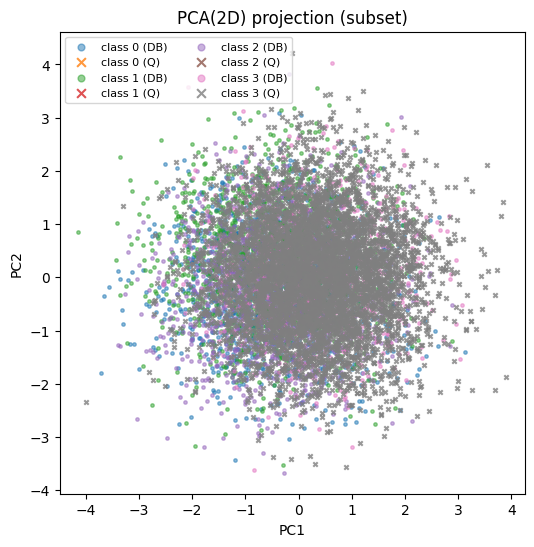

PCA explained variance ratio (PC1, PC2): [0.0367 0.0343]


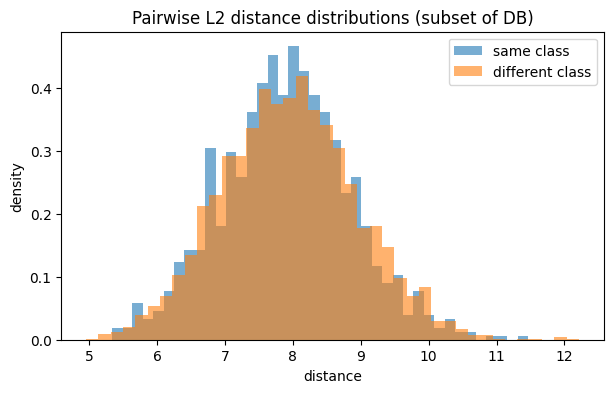

Mean distances — same: 7.905, different: 7.948


In [52]:
from sklearn.decomposition import PCA

y_db = y[:db_size]
y_q  = y[db_size:]

rng = np.random.default_rng(42)
max_points = 10000  # can adjust
idx_db = rng.choice(n_db, size=min(n_db, max_points // 2), replace=False)
idx_q  = rng.choice(n_q,  size=min(n_q,  max_points // 2), replace=False)

X_vis = np.vstack([database[idx_db], queries[idx_q]])
y_vis = np.hstack([y_db[idx_db],    y_q[idx_q]])
src   = np.array(["DB"] * len(idx_db) + ["Q"] * len(idx_q))

pca = PCA(n_components=2, random_state=42)
XY = pca.fit_transform(X_vis)

plt.figure(figsize=(6,6))
for label in np.unique(y_vis):
    mask_db = (y_vis == label) & (src == "DB")
    mask_q  = (y_vis == label) & (src == "Q")
    plt.scatter(XY[mask_db,0], XY[mask_db,1], s=6, alpha=0.5, label=f"class {label} (DB)", marker='o')
    plt.scatter(XY[mask_q,0],  XY[mask_q,1],  s=10, alpha=0.8, label=f"class {label} (Q)",  marker='x')

plt.title("PCA(2D) projection (subset)")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.axis('equal'); plt.legend(markerscale=2, fontsize=8, ncol=2)
plt.show()

print("PCA explained variance ratio (PC1, PC2):", np.round(pca.explained_variance_ratio_, 4))

def sample_pair_dist(X, labels, n_pairs=5000):
    d_same, d_diff = [], []
    n = X.shape[0]
    for _ in range(n_pairs):
        i, j = rng.integers(0, n), rng.integers(0, n)
        d = np.linalg.norm(X[i] - X[j])
        if labels[i] == labels[j]:
            d_same.append(d)
        else:
            d_diff.append(d)
    return np.array(d_same), np.array(d_diff)

d_same, d_diff = sample_pair_dist(database[idx_db], y_db[idx_db], n_pairs=4000)

plt.figure(figsize=(7,4))
bins = 40
plt.hist(d_same, bins=bins, alpha=0.6, density=True, label="same class")
plt.hist(d_diff, bins=bins, alpha=0.6, density=True, label="different class")
plt.title("Pairwise L2 distance distributions (subset of DB)")
plt.xlabel("distance"); plt.ylabel("density"); plt.legend()
plt.show()

print(f"Mean distances — same: {d_same.mean():.3f}, different: {d_diff.mean():.3f}")

# Metric Helpers

In [53]:
import math
from typing import List, Dict

def mrr_at_k(true_k: List[int], approx_k: List[int]) -> float:
    rel = set(true_k)
    for rank, idx in enumerate(approx_k, start=1):
        if idx in rel:
            return 1.0 / rank
    return 0.0

def average_precision_at_k(true_k: List[int], approx_k: List[int]) -> float:
    rel = set(true_k)
    hits = 0
    precisions = []
    for r, idx in enumerate(approx_k, start=1):
        if idx in rel:
            hits += 1
            precisions.append(hits / r)
    return (sum(precisions) / len(true_k)) if len(true_k) > 0 else 0.0

def ndcg_at_k(true_k: List[int], approx_k: List[int]) -> float:
    rel = set(true_k)
    dcg = 0.0
    for r, idx in enumerate(approx_k, start=1):
        if idx in rel:
            dcg += 1.0 / math.log2(r + 1)
    k = len(true_k)
    idcg = sum(1.0 / math.log2(r + 1) for r in range(1, k + 1))
    return dcg / idcg if idcg > 0 else 0.0

def eval_rank_metrics(true_lists: List[List[int]],
                      approx_lists: List[List[int]],
                      k: int) -> Dict[str, float]:
    mrrs = maps = ndcgs = 0.0
    n = len(true_lists)
    for i in range(n):
        t_k = true_lists[i][:k]
        a_k = approx_lists[i][:k]
        mrrs += mrr_at_k(t_k, a_k)
        maps += average_precision_at_k(t_k, a_k)
        ndcgs += ndcg_at_k(t_k, a_k)
    return {"MRR@k": mrrs / n, "MAP@k": maps / n, "nDCG@k": ndcgs / n}

# Exact Search (Brute Force)

In [54]:
from sklearn.neighbors import NearestNeighbors

MAX_K = max(K_LIST)

# Build exact index (fit is very fast for brute)
(nn_exact, build_time_exact) = time_call(
    NearestNeighbors(n_neighbors=MAX_K, algorithm='brute', metric='euclidean').fit,
    database
)
print(f"Exact (brute) build_time: {build_time_exact:.4f}s")

# Query once at MAX_K and reuse for all k
((dist_true, idx_true), query_time_exact) = time_call(
    nn_exact.kneighbors, queries, n_neighbors=MAX_K, return_distance=True
)
print(f"Exact (brute) avg_query_time_per_query: {query_time_exact / n_q:.6f}s")

# Ground-truth neighbor lists (one list per query)
true_nn_lists = [row.tolist() for row in idx_true]

Exact (brute) build_time: 0.0030s
Exact (brute) avg_query_time_per_query: 0.000081s


# Ball Tree

In [55]:
(nn_ball, build_time_ball) = time_call(
    NearestNeighbors(n_neighbors=MAX_K, algorithm='ball_tree', metric='euclidean').fit,
    database
)
print(f"BallTree build_time: {build_time_ball:.4f}s")

((dist_ball, idx_ball), query_time_ball) = time_call(
    nn_ball.kneighbors, queries, n_neighbors=MAX_K, return_distance=True
)

ball_lists = [row.tolist() for row in idx_ball]

# Evaluate vs ground truth for all K
ball_results = []
for k in K_LIST:
    P, R = evaluate_knn_lists(true_nn_lists, [row[:k] for row in ball_lists], k)
    ball_results.append({
        "method": "BallTree",
        "k": k,
        "build_time_s": build_time_ball,
        "avg_q_time_s": query_time_ball / n_q,
        "precision@k": P,
        "recall@k": R,
        "params": "metric=L2"
    })

print("BallTree first rows:", ball_results[:3])


BallTree build_time: 0.1643s
BallTree first rows: [{'method': 'BallTree', 'k': 1, 'build_time_s': 0.16427302360534668, 'avg_q_time_s': 0.004911711931228638, 'precision@k': 1.0, 'recall@k': 1.0, 'params': 'metric=L2'}, {'method': 'BallTree', 'k': 2, 'build_time_s': 0.16427302360534668, 'avg_q_time_s': 0.004911711931228638, 'precision@k': 1.0, 'recall@k': 1.0, 'params': 'metric=L2'}, {'method': 'BallTree', 'k': 3, 'build_time_s': 0.16427302360534668, 'avg_q_time_s': 0.004911711931228638, 'precision@k': 1.0, 'recall@k': 1.0, 'params': 'metric=L2'}]


# LSH

In [56]:


class E2LSH:
    def __init__(self, dim: int, L: int = 10, K: int = 5, w: float = 2.0, seed: int = SEED):
        self.dim, self.L, self.K, self.w = dim, L, K, w
        self.rng = np.random.default_rng(seed)
        self.A = self.rng.normal(0, 1, size=(L, K, dim)).astype(np.float32)
        self.b = self.rng.uniform(0, w, size=(L, K)).astype(np.float32)
        self.tables = [defaultdict(list) for _ in range(L)]
        self.data = None

    def _hash_vec(self, v: np.ndarray) -> List[Tuple[int,...]]:
        
        proj = (self.A @ v.astype(np.float32)) + self.b
        keys = np.floor(proj / self.w).astype(np.int32)
        return [tuple(keys[l]) for l in range(self.L)]

    def fit(self, X: np.ndarray):
        self.data = X.astype(np.float32, copy=False)
        for i, v in enumerate(self.data):
            keys = self._hash_vec(v)
            for l, key in enumerate(keys):
                self.tables[l][key].append(i)
        return self

    def query(self, q: np.ndarray, k: int) -> List[int]:
        cand = set()
        keys = self._hash_vec(q)
        for l, key in enumerate(keys):
            bucket = self.tables[l].get(key, [])
            cand.update(bucket)
        if not cand:
            cand = set(np.random.choice(self.data.shape[0], size=min(100, self.data.shape[0]), replace=False))
        cand = list(cand)
        Xc = self.data[cand]
        dists = np.linalg.norm(Xc - q[None, :], axis=1)
        top = np.argsort(dists)[:k]
        return [cand[i] for i in top]

lsh_params = dict(L=20, K=4, w=2.5)
(lsh, build_time_lsh) = time_call(E2LSH(vector_dim, **lsh_params).fit, database)
print(f"LSH build_time: {build_time_lsh:.4f}s | params={lsh_params}")

def lsh_batch_query(model: E2LSH, Q: np.ndarray, k: int) -> List[List[int]]:
    out = []
    for q in Q:
        out.append(model.query(q, k))
    return out

lsh_results = []
for k in K_LIST:
    (approx_lists, q_time) = time_call(lsh_batch_query, lsh, queries, k)
    P, R = evaluate_knn_lists(true_nn_lists, approx_lists, k)
    lsh_results.append({
        "method": "E2LSH",
        "k": k,
        "build_time_s": build_time_lsh,
        "avg_q_time_s": q_time / n_q,
        "precision@k": P,
        "recall@k": R,
        "params": f"L={lsh_params['L']},K={lsh_params['K']},w={lsh_params['w']}"
    })

print("LSH first rows:", lsh_results[:3])



LSH build_time: 3.1644s | params={'L': 20, 'K': 4, 'w': 2.5}
LSH first rows: [{'method': 'E2LSH', 'k': 1, 'build_time_s': 3.1644363403320312, 'avg_q_time_s': 0.00016339845657348633, 'precision@k': 0.0396, 'recall@k': 0.0396, 'params': 'L=20,K=4,w=2.5'}, {'method': 'E2LSH', 'k': 2, 'build_time_s': 3.1644363403320312, 'avg_q_time_s': 0.00016774239540100097, 'precision@k': 0.0401, 'recall@k': 0.0401, 'params': 'L=20,K=4,w=2.5'}, {'method': 'E2LSH', 'k': 3, 'build_time_s': 3.1644363403320312, 'avg_q_time_s': 0.00019818286895751953, 'precision@k': 0.039533333333333545, 'recall@k': 0.039533333333333545, 'params': 'L=20,K=4,w=2.5'}]


# ANNOY 

In [57]:
from annoy import AnnoyIndex


num_trees = 50
ann = AnnoyIndex(vector_dim, 'euclidean')

t0 = time.time()
for i, v in enumerate(database):
    ann.add_item(i, v.tolist())
ann.build(num_trees)
build_time_ann = time.time() - t0
print(f"Annoy build_time: {build_time_ann:.4f}s | trees={num_trees}")

def annoy_batch_query(index: AnnoyIndex, Q: np.ndarray, k: int, search_k: int = -1):
    return [index.get_nns_by_vector(q.tolist(), k, search_k=search_k) for q in Q]

ann_results = []
for k in K_LIST:
    (approx_lists, q_time) = time_call(annoy_batch_query, ann, queries, k, -1)
    P, R = evaluate_knn_lists(true_nn_lists, approx_lists, k)
    ann_results.append({
        "method": "Annoy",
        "k": k,
        "build_time_s": build_time_ann,
        "avg_q_time_s": q_time / n_q,
        "precision@k": P,
        "recall@k": R,
        "params": f"trees={num_trees},search_k=-1"
    })

print("Annoy first rows:", ann_results[:3])

Annoy build_time: 0.6238s | trees=50
Annoy first rows: [{'method': 'Annoy', 'k': 1, 'build_time_s': 0.623760461807251, 'avg_q_time_s': 3.626546859741211e-05, 'precision@k': 0.1484, 'recall@k': 0.1484, 'params': 'trees=50,search_k=-1'}, {'method': 'Annoy', 'k': 2, 'build_time_s': 0.623760461807251, 'avg_q_time_s': 4.601883888244629e-05, 'precision@k': 0.2032, 'recall@k': 0.2032, 'params': 'trees=50,search_k=-1'}, {'method': 'Annoy', 'k': 3, 'build_time_s': 0.623760461807251, 'avg_q_time_s': 5.58168888092041e-05, 'precision@k': 0.24206666666666646, 'recall@k': 0.24206666666666646, 'params': 'trees=50,search_k=-1'}]


# KD-Tree

In [58]:
(nn_kd, build_time_kd) = time_call(
    NearestNeighbors(n_neighbors=MAX_K, algorithm='kd_tree', metric='euclidean').fit,
    database
)
print(f"KD-Tree build_time: {build_time_kd:.4f}s")

((dist_kd, idx_kd), query_time_kd) = time_call(
    nn_kd.kneighbors, queries, n_neighbors=MAX_K, return_distance=True
)
kd_lists = [row.tolist() for row in idx_kd]

kd_results = []
for k in K_LIST:
    P, R = evaluate_knn_lists(true_nn_lists, [row[:k] for row in kd_lists], k)
    kd_results.append({
        "method": "KDTree",
        "k": k,
        "build_time_s": build_time_kd,
        "avg_q_time_s": query_time_kd / n_q,
        "precision@k": P,
        "recall@k": R,
        "params": "metric=L2"
    })

print("KD-Tree first rows:", kd_results[:3])


KD-Tree build_time: 0.2423s
KD-Tree first rows: [{'method': 'KDTree', 'k': 1, 'build_time_s': 0.2422776222229004, 'avg_q_time_s': 0.004762643194198608, 'precision@k': 1.0, 'recall@k': 1.0, 'params': 'metric=L2'}, {'method': 'KDTree', 'k': 2, 'build_time_s': 0.2422776222229004, 'avg_q_time_s': 0.004762643194198608, 'precision@k': 1.0, 'recall@k': 1.0, 'params': 'metric=L2'}, {'method': 'KDTree', 'k': 3, 'build_time_s': 0.2422776222229004, 'avg_q_time_s': 0.004762643194198608, 'precision@k': 1.0, 'recall@k': 1.0, 'params': 'metric=L2'}]


# HNSW

In [59]:
import hnswlib

space = 'l2'  
M = 32
efC = 200
efS = 100

p = hnswlib.Index(space=space, dim=vector_dim)
t0 = time.time()  
p.init_index(max_elements=n_db, ef_construction=efC, M=M, random_seed=SEED)
p.add_items(database, np.arange(n_db))
p.set_ef(efS)
build_time_hnsw = time.time() - t0

print(f"HNSW build_time: {build_time_hnsw:.4f}s | M={M}, efConstruction={efC}, efSearch={efS}")

def hnsw_batch_query(index, Q: np.ndarray, k: int):
    labels, _ = index.knn_query(Q, k=k)
    return [row.tolist() for row in labels]

hnsw_results = []
for k in K_LIST:
    (approx_lists, q_time) = time_call(hnsw_batch_query, p, queries, k)
    P, R = evaluate_knn_lists(true_nn_lists, approx_lists, k)
    hnsw_results.append({
        "method": "HNSW",
        "k": k,
        "build_time_s": build_time_hnsw,
        "avg_q_time_s": q_time / n_q,
        "precision@k": P,
        "recall@k": R,
        "params": f"M={M},efC={efC},efS={efS}"
    })

print("HNSW first rows:", hnsw_results[:3])



HNSW build_time: 1.0886s | M=32, efConstruction=200, efSearch=100
HNSW first rows: [{'method': 'HNSW', 'k': 1, 'build_time_s': 1.088562250137329, 'avg_q_time_s': 1.3832283020019532e-05, 'precision@k': 0.9976, 'recall@k': 0.9976, 'params': 'M=32,efC=200,efS=100'}, {'method': 'HNSW', 'k': 2, 'build_time_s': 1.088562250137329, 'avg_q_time_s': 1.2076759338378906e-05, 'precision@k': 0.9957, 'recall@k': 0.9957, 'params': 'M=32,efC=200,efS=100'}, {'method': 'HNSW', 'k': 3, 'build_time_s': 1.088562250137329, 'avg_q_time_s': 1.2554645538330078e-05, 'precision@k': 0.9948666666666671, 'recall@k': 0.9948666666666671, 'params': 'M=32,efC=200,efS=100'}]


# Visualisations

,method,k,build_time_s,avg_q_time_s,precision@k,recall@k,params
0,ExactBrute,1,0.00302,0.000081,1.0,1.0,algorithm=brute
1,ExactBrute,2,0.00302,0.000081,1.0,1.0,algorithm=brute
2,ExactBrute,3,0.00302,0.000081,1.0,1.0,algorithm=brute
3,ExactBrute,5,0.00302,0.000081,1.0,1.0,algorithm=brute
4,ExactBrute,10,0.00302,0.000081,1.0,1.0,algorithm=brute


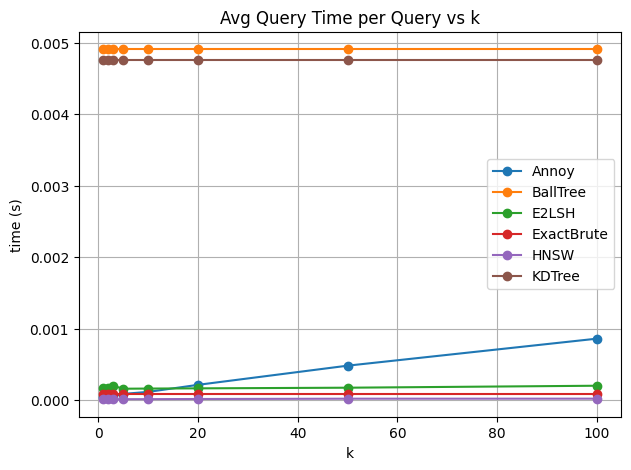

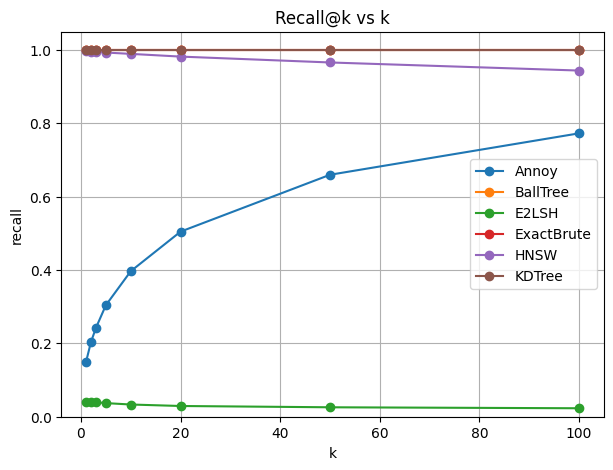

In [60]:
exact_row = [{
    "method": "ExactBrute",
    "k": k,
    "build_time_s": 0.0 + build_time_exact,
    "avg_q_time_s": (query_time_exact / n_q),
    "precision@k": 1.0,
    "recall@k": 1.0,
    "params": "algorithm=brute"
} for k in K_LIST]

results = pd.DataFrame(
    exact_row + ball_results + kd_results + lsh_results + ann_results + hnsw_results
)
display(results.head())

# Plots Query time vs k & Recall vs k
plt.figure(figsize=(7,5))
for method, dfm in results.groupby("method"):
    plt.plot(dfm["k"], dfm["avg_q_time_s"], marker='o', label=method)
plt.title("Avg Query Time per Query vs k")
plt.xlabel("k"); plt.ylabel("time (s)"); plt.grid(True); plt.legend()
plt.show()

plt.figure(figsize=(7,5))
for method, dfm in results.groupby("method"):
    plt.plot(dfm["k"], dfm["recall@k"], marker='o', label=method)
plt.title("Recall@k vs k")
plt.xlabel("k"); plt.ylabel("recall"); plt.ylim(0,1.05); plt.grid(True); plt.legend()
plt.show()


In [61]:
def _to_df(rows, name):
    df = pd.DataFrame(rows)
    if len(df) == 0:
        return df
    if "method" not in df.columns:
        df["method"] = name
    return df

tables = []
if "results" in globals():
    df_long = results.copy()
else:
    tables.append(_to_df(locals().get("ball_results", []), "BallTree"))
    tables.append(_to_df(locals().get("kd_results", []),   "KDTree"))
    tables.append(_to_df(locals().get("lsh_results", []),  "E2LSH"))
    tables.append(_to_df(locals().get("ann_results", []),  "Annoy"))
    tables.append(_to_df(locals().get("hnsw_results", []), "HNSW"))
    exact_rows = []
    if "build_time_exact" in globals() and "query_time_exact" in globals() and "K_LIST" in globals():
        exact_rows = [{
            "method": "ExactBrute",
            "k": k,
            "build_time_s": build_time_exact,
            "avg_q_time_s": (query_time_exact / n_q),
            "precision@k": 1.0,
            "recall@k": 1.0,
            "params": "algorithm=brute"
        } for k in K_LIST]
    tables.append(_to_df(exact_rows, "ExactBrute"))
    df_long = pd.concat([t for t in tables if len(t)], ignore_index=True)

df_long["F1@k"] = 2 * (df_long["precision@k"] * df_long["recall@k"]) / ((df_long["precision@k"] + df_long["recall@k"]).replace(0, np.nan))
df_long["F1@k"] = df_long["F1@k"].fillna(0.0)


def make_wide(df, metric_col, add_mean=True, sort_by="recall@k"):
    wide = df.pivot(index="method", columns="k", values=metric_col).sort_index()
    if add_mean:
        wide["mean"] = df.groupby("method")[metric_col].mean().reindex(wide.index)
    if sort_by == "recall@k" and "recall@k" in df.columns:
        order = df.groupby("method")["recall@k"].mean().sort_values(ascending=False).index
        wide = wide.reindex(order)
    return wide

precision_table = make_wide(df_long, "precision@k")
recall_table    = make_wide(df_long, "recall@k")
f1_table        = make_wide(df_long, "F1@k")

def style_table(tbl, title):
    styled = (tbl.style
              .format("{:.3f}")
              .set_caption(title)
              .background_gradient(axis=None))
    return styled

display(style_table(precision_table, "Precision@k by Method"))
display(style_table(recall_table,    "Recall@k by Method"))
display(style_table(f1_table,        "F1@k by Method"))

k,1,2,3,5,10,20,50,100,mean
method,,,,,,,,,
BallTree,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000
ExactBrute,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000
KDTree,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000
HNSW,0.998,0.996,0.995,0.993,0.990,0.982,0.966,0.944,0.983
Annoy,0.148,0.203,0.242,0.304,0.397,0.505,0.660,0.773,0.404
E2LSH,0.040,0.040,0.040,0.037,0.033,0.029,0.026,0.023,0.033


k,1,2,3,5,10,20,50,100,mean
method,,,,,,,,,
BallTree,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000
ExactBrute,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000
KDTree,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000
HNSW,0.998,0.996,0.995,0.993,0.990,0.982,0.966,0.944,0.983
Annoy,0.148,0.203,0.242,0.304,0.397,0.505,0.660,0.773,0.404
E2LSH,0.040,0.040,0.040,0.037,0.033,0.029,0.026,0.023,0.033


k,1,2,3,5,10,20,50,100,mean
method,,,,,,,,,
BallTree,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000
ExactBrute,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000
KDTree,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000
HNSW,0.998,0.996,0.995,0.993,0.990,0.982,0.966,0.944,0.983
Annoy,0.148,0.203,0.242,0.304,0.397,0.505,0.660,0.773,0.404
E2LSH,0.040,0.040,0.040,0.037,0.033,0.029,0.026,0.023,0.033


# Runtime comparison tables 

In [62]:

def _to_df(rows, name):
    df = pd.DataFrame(rows)
    if len(df) and "method" not in df.columns:
        df["method"] = name
    return df

if "results" in globals():
    df = results.copy()
else:
    pieces = []
    pieces.append(_to_df(locals().get("ball_results", []), "BallTree"))
    pieces.append(_to_df(locals().get("kd_results", []),   "KDTree"))
    pieces.append(_to_df(locals().get("lsh_results", []),  "E2LSH"))
    pieces.append(_to_df(locals().get("ann_results", []),  "Annoy"))
    pieces.append(_to_df(locals().get("hnsw_results", []), "HNSW"))

    if all(x in globals() for x in ["build_time_exact", "query_time_exact", "K_LIST", "n_q"]):
        pieces.append(pd.DataFrame([{
            "method":"ExactBrute", "k":k,
            "build_time_s": build_time_exact,
            "avg_q_time_s": query_time_exact / n_q,
            "precision@k": 1.0, "recall@k": 1.0, "params": "algorithm=brute"
        } for k in K_LIST]))
    df = pd.concat([p for p in pieces if p is not None and len(p)], ignore_index=True)


build_time_tbl = (df.groupby("method", as_index=True)["build_time_s"]
                    .mean()      
                    .to_frame())
build_time_tbl["build_time_s"] = build_time_tbl["build_time_s"].round(4)
build_time_tbl["x_faster_vs_fastest"] = (build_time_tbl["build_time_s"].min() /
                                         build_time_tbl["build_time_s"]).replace([np.inf, 0], np.nan).round(2)

qtime_tbl = df.pivot(index="method", columns="k", values="avg_q_time_s").sort_index().round(6)

qps_tbl = (1.0 / qtime_tbl.replace(0, np.nan)).round(2)

if "ExactBrute" in qtime_tbl.index:
    exact_row = qtime_tbl.loc["ExactBrute"]
    speedup_tbl = (exact_row / qtime_tbl).replace([np.inf, -np.inf], np.nan).round(2)
else:
    speedup_tbl = pd.DataFrame(index=qtime_tbl.index, columns=qtime_tbl.columns, dtype=float)
    print("Note: ExactBrute not found; speedup table will be empty.")

if "n_q" in globals():
    total_time_tbl = (qtime_tbl * n_q).round(4)
else:
    total_time_tbl = None

def style_table(tbl, title):
    try:
        import jinja2 
        return (tbl.style
                  .format("{:.6f}" if "time" in title.lower() else "{:.2f}")
                  .set_caption(title)
                  .background_gradient(axis=None))
    except Exception:
        print(f"(Plain table) — {title}")
        return tbl

display(style_table(build_time_tbl, "Build Time (s) & Relative to Fastest"))
display(style_table(qtime_tbl,      "Avg Query Time per Query (s) by k"))
display(style_table(qps_tbl,        "Throughput (Queries/Second) by k"))
display(style_table(speedup_tbl,    "Speedup vs ExactBrute (×) by k"))

if total_time_tbl is not None:
    display(style_table(total_time_tbl, "Total Time for All Queries (s) by k"))

,build_time_s,x_faster_vs_fastest
method,,
Annoy,0.623800,0.000000
BallTree,0.164300,0.020000
E2LSH,3.164400,0.000000
ExactBrute,0.003000,1.000000
HNSW,1.088600,0.000000
KDTree,0.242300,0.010000


k,1,2,3,5,10,20,50,100
method,,,,,,,,
Annoy,0.000036,0.000046,0.000056,0.000087,0.000115,0.000214,0.000482,0.000859
BallTree,0.004912,0.004912,0.004912,0.004912,0.004912,0.004912,0.004912,0.004912
E2LSH,0.000163,0.000168,0.000198,0.000159,0.000161,0.000164,0.000173,0.000201
ExactBrute,0.000081,0.000081,0.000081,0.000081,0.000081,0.000081,0.000081,0.000081
HNSW,0.000014,0.000012,0.000013,0.000013,0.000013,0.000015,0.000020,0.000020
KDTree,0.004763,0.004763,0.004763,0.004763,0.004763,0.004763,0.004763,0.004763


k,1,2,3,5,10,20,50,100
method,,,,,,,,
Annoy,27777.78,21739.13,17857.14,11494.25,8695.65,4672.90,2074.69,1164.14
BallTree,203.58,203.58,203.58,203.58,203.58,203.58,203.58,203.58
E2LSH,6134.97,5952.38,5050.51,6289.31,6211.18,6097.56,5780.35,4975.12
ExactBrute,12345.68,12345.68,12345.68,12345.68,12345.68,12345.68,12345.68,12345.68
HNSW,71428.57,83333.33,76923.08,76923.08,76923.08,66666.67,50000.00,50000.00
KDTree,209.95,209.95,209.95,209.95,209.95,209.95,209.95,209.95


k,1,2,3,5,10,20,50,100
method,,,,,,,,
Annoy,2.25,1.76,1.45,0.93,0.70,0.38,0.17,0.09
BallTree,0.02,0.02,0.02,0.02,0.02,0.02,0.02,0.02
E2LSH,0.50,0.48,0.41,0.51,0.50,0.49,0.47,0.40
ExactBrute,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
HNSW,5.79,6.75,6.23,6.23,6.23,5.40,4.05,4.05
KDTree,0.02,0.02,0.02,0.02,0.02,0.02,0.02,0.02


k,1,2,3,5,10,20,50,100
method,,,,,,,,
Annoy,0.180000,0.230000,0.280000,0.435000,0.575000,1.070000,2.410000,4.295000
BallTree,24.560000,24.560000,24.560000,24.560000,24.560000,24.560000,24.560000,24.560000
E2LSH,0.815000,0.840000,0.990000,0.795000,0.805000,0.820000,0.865000,1.005000
ExactBrute,0.405000,0.405000,0.405000,0.405000,0.405000,0.405000,0.405000,0.405000
HNSW,0.070000,0.060000,0.065000,0.065000,0.065000,0.075000,0.100000,0.100000
KDTree,23.815000,23.815000,23.815000,23.815000,23.815000,23.815000,23.815000,23.815000


# Evaluate MRR@k, MAP@k, nDCG@k across methods and K_LIST 

In [63]:
def get_or_compute_lists(method_name: str):
    global true_nn_lists, idx_ball, idx_kd, lsh, ann, p, queries, database, MAX_K

    if method_name == "ExactBrute":
        if "true_nn_lists" not in globals():
            raise ValueError("Run the Exact (Block 3) first to compute true_nn_lists.")
        return true_nn_lists

    if method_name == "BallTree":
        if "idx_ball" in globals():
            return [row.tolist() for row in idx_ball]
        else:
            from sklearn.neighbors import NearestNeighbors
            nn = NearestNeighbors(n_neighbors=MAX_K, algorithm='ball_tree', metric='euclidean').fit(database)
            idx = nn.kneighbors(queries, n_neighbors=MAX_K, return_distance=False)
            return [row.tolist() for row in idx]

    if method_name == "KDTree":
        if "idx_kd" in globals():
            return [row.tolist() for row in idx_kd]
        else:
            from sklearn.neighbors import NearestNeighbors
            nn = NearestNeighbors(n_neighbors=MAX_K, algorithm='kd_tree', metric='euclidean').fit(database)
            idx = nn.kneighbors(queries, n_neighbors=MAX_K, return_distance=False)
            return [row.tolist() for row in idx]

    if method_name == "E2LSH":
        if "lsh" not in globals():
            raise ValueError("LSH model 'lsh' not found; run the LSH block first.")
        if "lsh_batch_query" in globals():
            return lsh_batch_query(lsh, queries, MAX_K)
        return [lsh.query(q, MAX_K) for q in queries]

    if method_name == "Annoy":
        if "ann" not in globals():
            raise ValueError("Annoy index 'ann' not found; run the Annoy block first.")
        if "annoy_batch_query" in globals():
            return annoy_batch_query(ann, queries, MAX_K, -1)
        return [ann.get_nns_by_vector(q.tolist(), MAX_K, search_k=-1) for q in queries]

    if method_name == "HNSW":
        if "p" not in globals():
            raise ValueError("HNSW index 'p' not found; run the HNSW block first.")
        if "hnsw_batch_query" in globals():
            return hnsw_batch_query(p, queries, MAX_K)
        labels, _ = p.knn_query(queries, k=MAX_K)
        return [row.tolist() for row in labels]

    raise ValueError(f"Unknown method: {method_name}")

METHODS = []
if "true_nn_lists" in globals(): METHODS.append("ExactBrute")
if "nn_ball" in globals() or "idx_ball" in globals(): METHODS.append("BallTree")
if "nn_kd"   in globals() or "idx_kd"   in globals(): METHODS.append("KDTree")
if "lsh"     in globals(): METHODS.append("E2LSH")
if "ann"     in globals(): METHODS.append("Annoy")
if "p"       in globals(): METHODS.append("HNSW")

method_lists = {m: get_or_compute_lists(m) for m in METHODS}

print("Ready methods:", METHODS)



Ready methods: ['ExactBrute', 'BallTree', 'KDTree', 'E2LSH', 'Annoy', 'HNSW']


In [64]:
rows = []
for m in METHODS:
    approx_lists_full = method_lists[m]
    for k in K_LIST:
        metrics = eval_rank_metrics(true_nn_lists, approx_lists_full, k)
        rows.append({
            "method": m,
            "k": k,
            "MRR@k": metrics["MRR@k"],
            "MAP@k": metrics["MAP@k"],
            "nDCG@k": metrics["nDCG@k"],
        })

rank_metrics_df = pd.DataFrame(rows).sort_values(["method", "k"]).reset_index(drop=True)
display(rank_metrics_df.head())

,method,k,MRR@k,MAP@k,nDCG@k
0,Annoy,1,0.9698,0.969800,0.969800
1,Annoy,2,0.9984,0.963200,0.971166
2,Annoy,3,0.9998,0.956267,0.968775
3,Annoy,5,1.0000,0.942800,0.961924
4,Annoy,10,1.0000,0.918580,0.947294


In [65]:
def wide_metric(df, metric):
    return df.pivot(index="method", columns="k", values=metric).sort_index()

mrr_w  = wide_metric(rank_metrics_df, "MRR@k").round(4)
map_w  = wide_metric(rank_metrics_df, "MAP@k").round(4)
ndcg_w = wide_metric(rank_metrics_df, "nDCG@k").round(4)

print("\nMRR@k (methods × k):")
display(mrr_w)
print("\nMAP@k (methods × k):")
display(map_w)
print("\nnDCG@k (methods × k):")
display(ndcg_w)


MRR@k (methods × k):


k,1,2,3,5,10,20,50,100
method,,,,,,,,
Annoy,0.9698,0.9984,0.9998,1.0000,1.0000,1.0000,1.0000,1.000
BallTree,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.000
E2LSH,0.0396,0.0782,0.1132,0.1698,0.2802,0.4328,0.7016,0.874
ExactBrute,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.000
HNSW,0.9976,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.000
KDTree,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.000



MAP@k (methods × k):


k,1,2,3,5,10,20,50,100
method,,,,,,,,
Annoy,0.9698,0.9632,0.9563,0.9428,0.9186,0.8858,0.8281,0.7729
BallTree,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
E2LSH,0.0396,0.0401,0.0395,0.0371,0.0333,0.0293,0.0257,0.0231
ExactBrute,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
HNSW,0.9976,0.9957,0.9949,0.9932,0.9896,0.9822,0.9661,0.9441
KDTree,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000



nDCG@k (methods × k):


k,1,2,3,5,10,20,50,100
method,,,,,,,,
Annoy,0.9698,0.9712,0.9688,0.9619,0.9473,0.9246,0.8797,0.8325
BallTree,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
E2LSH,0.0396,0.0487,0.0547,0.0609,0.0688,0.0745,0.0801,0.0781
ExactBrute,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
HNSW,0.9976,0.9967,0.9964,0.9956,0.9933,0.9884,0.9767,0.9596
KDTree,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
